In [1]:
# ============================================================
# E4 Wristband Sleep Staging
# Channels: BVP, HR, TEMP (3 channels, 64Hz, 1920 samples/epoch)
# Architecture: Triple-CNN + BiMamba + SupCon
# Artifact weighting: EEG TSV weights applied to E4
#
# Reference for channel selection:
#   Parry & Briganti (2026): HR and TEMP valid for sleep staging;
#   EDA tonic component unreliable at wrist during sleep.
# ============================================================

import os
import csv
import math
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import (
    accuracy_score, f1_score,
    cohen_kappa_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# ============================================================
# PATHS & CONFIG
# ============================================================
E4_PATH      = r"D:\22\AA\preprocess\preprocessed_E4_v3_BHT"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH    = r"D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon"
os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES   = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT       = 7
WINDOW        = 2 * CONTEXT + 1
N_EPOCHS      = 30
BATCH_SIZE    = 64
SEEDS         = [42, 123, 256, 789, 999]
IN_CH         = 3      # BVP, HR, TEMP
EPOCH_SAMPLES = 1920   # 64Hz × 30s

D_MODEL       = 128
D_STATE       = 16
DROPOUT       = 0.4
SUPCON_LAMBDA = 0.2
SUPCON_TEMP   = 0.05
PROJ_DIM      = 64

ARTIFACT_WEIGHT_MAP   = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_ART_CHANNELS   = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_ART_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"Channels      : BVP, HR, TEMP  (in_ch={IN_CH})")
print(f"Epoch samples : {EPOCH_SAMPLES}  (64Hz × 30s)")
print(f"Architecture  : Triple-CNN + BiMamba + SupCon")
print(f"Output        : {EVAL_PATH}")

# ============================================================
# LOAD SPLIT
# ============================================================
TRAIN_SUBS = np.load(os.path.join(E4_PATH, '_train_subs.npy'), allow_pickle=True).tolist()
TEST_SUBS  = np.load(os.path.join(E4_PATH, '_test_subs.npy'),  allow_pickle=True).tolist()
print(f"Train: {len(TRAIN_SUBS)}  Test: {len(TEST_SUBS)}")
print(f"TEST_SUBS: {TEST_SUBS}")


# ============================================================
# ARTIFACT WEIGHT LOADER
# ============================================================
def load_artifact_weights(subject_id, n_epochs):
    tsv_path = os.path.join(
        ARTIFACT_PATH, subject_id, "eeg",
        f"{subject_id}_task-sleep_proc-artifacts.tsv"
    )
    if not os.path.exists(tsv_path):
        return np.ones(n_epochs, dtype=np.float32)
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return np.ones(n_epochs, dtype=np.float32)

    available = [ch for ch in TARGET_ART_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_ART_CHANNELS if ch in df.columns]
    if not available:
        return np.ones(n_epochs, dtype=np.float32)

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // 30).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    weights = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        idx = int(ep_idx)
        if 0 <= idx < n_epochs:
            weights[idx] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# DATASET
# ============================================================
class E4Dataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data    = []
        self.index   = []
        label_counter  = Counter()
        weight_counter = Counter()

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                e4     = d['e4'].astype(np.float32)   # (N, 3, 1920)
                labels = d['labels'].copy()

            n = len(labels)

            # Try loading weights from npz first, else load from TSV
            try:
                with np.load(fp) as d:
                    if 'weights' in d:
                        art_w = d['weights'].astype(np.float32)
                    else:
                        art_w = load_artifact_weights(sub, n)
            except Exception:
                art_w = load_artifact_weights(sub, n)

            # Align length
            if len(art_w) >= n:
                art_w = art_w[:n]
            else:
                art_w = np.concatenate([art_w, np.ones(n - len(art_w), dtype=np.float32)])

            sub_idx = len(self.data)
            self.data.append((e4, labels, art_w))

            for i in range(n):
                w = float(art_w[i])
                self.index.append((sub_idx, i, n, w))
                label_counter[int(labels[i])] += 1
                weight_counter[round(w, 1)]   += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(5)], dtype=np.float32
        )

        total = len(self.index)
        ram   = sum(e.nbytes for e, _, _ in self.data) / 1e9
        print(f"  Samples : {total:,}")
        print(f"  RAM     : {ram:.2f} GB")
        print(f"  Weight distribution:")
        for w in sorted(weight_counter.keys(), reverse=True):
            pct = weight_counter[w] / total * 100
            print(f"    w={w:.1f} : {weight_counter[w]:>7,} ({pct:.1f}%)")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        e4, labels, _ = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(e4[ei])

        x = np.stack(window_epochs, axis=0)   # (W, 3, 1920)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


print("\nBuilding datasets...")
train_ds = E4Dataset(TRAIN_SUBS, E4_PATH)
print()
test_ds  = E4Dataset(TEST_SUBS,  E4_PATH)
print("Datasets ready.")


# ============================================================
# MODEL — Triple CNN + BiMamba + SupCon
# EPOCH_SAMPLES=1920 (64Hz) instead of 7680 (256Hz)
# ============================================================
class TripleResCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 3

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel,
                          stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=5, padding=2),
                nn.BatchNorm1d(mid), nn.GELU(),
                nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        # Smaller kernels for 64Hz (proportional to 256Hz kernels / 4)
        self.small  = branch(7)    # ~25/4
        self.medium = branch(13)   # ~50/4
        self.large  = branch(25)   # ~100/4

        with torch.no_grad():
            dummy  = torch.zeros(1, in_ch, EPOCH_SAMPLES)
            L_s    = self.small(dummy).shape[2]
            L_m    = self.medium(dummy).shape[2]
            L_l    = self.large(dummy).shape[2]

        target_L     = min(L_s, L_m, L_l)
        self.pool_s  = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m  = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l  = nn.AdaptiveAvgPool1d(target_L)
        self.out_len = target_L

        self.proj = nn.Sequential(
            nn.Conv1d(3 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))
        return self.proj(torch.cat([fs, fm, fl], dim=1))


class MambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE,
                 d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, padding=d_conv - 1,
            groups=self.d_inner, bias=True
        )
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.expand(self.d_inner, -1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_size, L, d = x.shape
        h  = torch.zeros(B_size, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            h  = h * A.unsqueeze(0) + xi.unsqueeze(-1) * B[:, i, :].unsqueeze(1)
            y  = (h * C[:, i, :].unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        residual = x
        B, L, _  = x.shape
        xz       = self.in_proj(x)
        x_, z    = xz.chunk(2, dim=-1)
        x_       = F.silu(self.conv1d(x_.transpose(1,2))[:,:,:L].transpose(1,2))
        ssm_p    = self.x_proj(x_)
        dt_r, Bp, Cp = ssm_p.split([1, self.d_state, self.d_state], dim=-1)
        dt       = F.softplus(self.dt_proj(dt_r))
        A        = -torch.exp(self.A_log)
        A_disc   = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)).mean(1).mean(0)
        y        = self.ssm_scan(x_, A_disc, Bp, Cp, self.D)
        y        = self.out_proj(self.dropout(y * F.silu(z)))
        return self.norm(y + residual)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, dropout=DROPOUT):
        super().__init__()
        self.fwd  = MambaBlock(d_model, d_state, dropout=dropout)
        self.bwd  = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.fwd(x)
        bwd = torch.flip(self.bwd(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class E4BitMamSleep(nn.Module):
    def __init__(
        self, in_ch=IN_CH, d_model=D_MODEL, d_state=D_STATE,
        n_layers=2, dropout=DROPOUT,
        n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM
    ):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.triple_cnn    = TripleResCNN(in_ch, d_model, dropout)
        self.intra_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)
        ])
        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[
            BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)
        ])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out    = self.triple_cnn(x.view(B*W, C, T)).permute(0,2,1)
        intra      = self.intra_bimamba(cnn_out).mean(dim=1).view(B, W, self.d_model)
        inter      = self.inter_bimamba(intra + self.inter_pos)
        center     = inter[:, self.context, :]
        logits     = self.classifier(center)
        proj       = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOSS
# ============================================================
class SupConLoss(nn.Module):
    def __init__(self, temperature=SUPCON_TEMP):
        super().__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        B      = features.shape[0]
        device = features.device
        sim    = torch.matmul(features, features.T) / self.temperature
        sim    = sim - sim.max(dim=1, keepdim=True)[0].detach()
        pos    = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        sm     = torch.eye(B, device=device)
        pos    = pos - sm
        denom  = torch.exp(sim) * (1 - sm)
        lp     = sim - torch.log(denom.sum(1, keepdim=True) + 1e-8)
        n_pos  = pos.sum(1)
        am     = (n_pos > 0).float()
        loss   = -(pos * lp).sum(1) / (n_pos + 1e-8)
        return (loss * am).sum() / (am.sum() + 1e-8)


supcon_loss = SupConLoss()
cw_np = train_ds.label_counts.sum() / (5 * train_ds.label_counts)
cw    = torch.FloatTensor(cw_np).to(device)

print(f"\nClass weights:")
for name, w in zip(LABEL_NAMES, cw_np):
    print(f"  {name}: {w:.3f}")


def combined_loss(logits, proj, labels, weights):
    ce    = nn.CrossEntropyLoss(weight=cw, reduction='none')(logits, labels)
    wce   = ce * weights
    valid = weights > 0
    if valid.sum() == 0:
        l_ce = wce.mean()
    else:
        l_ce = wce[valid].mean()
    l_sc = supcon_loss(proj, labels)
    return l_ce + SUPCON_LAMBDA * l_sc, l_ce.item(), l_sc.item()


# ============================================================
# HELPERS
# ============================================================
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    tl = tc = ts = 0
    preds, labs = [], []
    for x, y, w in loader:
        x, y, w = x.to(device), y.to(device), w.to(device)
        optimizer.zero_grad()
        logits, proj        = model(x)
        loss, lc, ls        = combined_loss(logits, proj, y, w)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        tl += loss.item(); tc += lc; ts += ls
        preds.extend(logits.argmax(1).cpu().numpy())
        labs.extend(y.cpu().numpy())
    n = len(loader)
    return tl/n, tc/n, ts/n, accuracy_score(labs, preds), \
           f1_score(labs, preds, average='macro', zero_division=0)


def evaluate(model, loader):
    model.eval()
    preds, labs, weights_all = [], [], []
    with torch.no_grad():
        for x, y, w in loader:
            logits, _ = model(x.to(device))
            preds.extend(logits.argmax(1).cpu().numpy())
            labs.extend(y.numpy())
            weights_all.extend(w.numpy())
    preds = np.array(preds); labs = np.array(labs)
    weights_all = np.array(weights_all)
    acc   = accuracy_score(labs, preds)
    f1    = f1_score(labs, preds, average='macro', zero_division=0)
    kappa = cohen_kappa_score(labs, preds)
    per   = f1_score(labs, preds, average=None, zero_division=0)
    clean_mask = weights_all == 1.0
    noisy_mask = (weights_all > 0) & (weights_all < 1.0)
    c_acc = accuracy_score(labs[clean_mask], preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
    n_acc = accuracy_score(labs[noisy_mask], preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0
    return acc, f1, kappa, per, preds, labs, c_acc, n_acc


# ============================================================
# CSV SETUP
# ============================================================
csv_epoch = os.path.join(EVAL_PATH, "epoch_log.csv")
with open(csv_epoch, 'w', newline='') as f:
    csv.writer(f).writerow([
        'seed','epoch','tr_loss','tr_ce','tr_sc',
        'tr_acc','tr_f1','vl_acc','vl_f1','vl_kappa','clean_acc','noisy_acc'
    ])

csv_summary = os.path.join(EVAL_PATH, "summary.csv")
fields = ["seed","acc","f1_macro","kappa",
          "f1_Wake","f1_N1","f1_N2","f1_N3","f1_REM","clean_acc","noisy_acc"]
with open(csv_summary, 'w', newline='') as f:
    csv.DictWriter(f, fields).writeheader()


# ============================================================
# 5-SEED TRAINING
# ============================================================
all_results = []

for seed_idx, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"SEED {seed}  ({seed_idx+1}/{len(SEEDS)})")
    print(f"{'='*60}")

    set_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=0, generator=torch.Generator().manual_seed(seed)
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    model    = E4BitMamSleep().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Parameters: {n_params:,}")

    optimizer = optim.AdamW(
        model.parameters(), lr=5e-4, weight_decay=3e-4,
        betas=(0.9, 0.98), eps=1e-9
    )
    total_steps  = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_fn(step):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        t = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * t))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_fn)

    best_f1   = 0.0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")

    for epoch in range(1, N_EPOCHS + 1):
        tl, tc, ts, tr_acc, tr_f1 = train_epoch(
            model, train_loader, optimizer, scheduler
        )
        acc, f1, kap, per, _, _, c_acc, n_acc = evaluate(model, test_loader)

        saved = ""
        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]['lr']
        print(
            f"  Ep[{epoch:02d}/{N_EPOCHS}] "
            f"Loss:{tl:.3f}(CE:{tc:.3f}+SC:{ts:.3f}) "
            f"TrAcc:{tr_acc:.3f} ValAcc:{acc:.3f} "
            f"F1:{f1:.3f} k:{kap:.3f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("    Per-class: " + " | ".join(
                f"{LABEL_NAMES[i]}={per[i]:.3f}" for i in range(5)
            ))
            print(f"    Clean:{c_acc:.3f}  Noisy:{n_acc:.3f}")

        with open(csv_epoch, 'a', newline='') as f_:
            csv.writer(f_).writerow([
                seed, epoch,
                f"{tl:.4f}", f"{tc:.4f}", f"{ts:.4f}",
                f"{tr_acc:.4f}", f"{tr_f1:.4f}",
                f"{acc:.4f}", f"{f1:.4f}", f"{kap:.4f}",
                f"{c_acc:.4f}", f"{n_acc:.4f}"
            ])

    # Final eval
    model.load_state_dict(torch.load(best_path, map_location=device))
    fin_acc, fin_f1, fin_kap, fin_per, fin_preds, fin_labs, fin_c, fin_n = evaluate(
        model, test_loader
    )

    print(f"\n  Seed {seed} FINAL:")
    print(f"  {'='*51}")
    print(f"  Accuracy    : {fin_acc*100:.2f}%")
    print(f"  Macro F1    : {fin_f1:.4f}")
    print(f"  Cohen Kappa : {fin_kap:.4f}")
    print(f"  Clean Acc   : {fin_c*100:.2f}%")
    print(f"  Noisy Acc   : {fin_n*100:.2f}%")
    print(f"  {'-'*51}")
    print("  Per-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        bar = chr(9608) * int(fin_per[i] * 16)
        print(f"    {name:6s}: {fin_per[i]:.4f}  {bar}")
    print(f"  {'='*51}")

    result = {
        'seed': seed, 'acc': fin_acc, 'f1': fin_f1,
        'kappa': fin_kap, 'per_cls': fin_per,
        'preds': fin_preds, 'labels': fin_labs,
    }
    all_results.append(result)

    with open(csv_summary, 'a', newline='') as f_:
        csv.DictWriter(f_, fields).writerow({
            "seed":      seed,
            "acc":       round(fin_acc,    4),
            "f1_macro":  round(fin_f1,     4),
            "kappa":     round(fin_kap,    4),
            "f1_Wake":   round(fin_per[0], 4),
            "f1_N1":     round(fin_per[1], 4),
            "f1_N2":     round(fin_per[2], 4),
            "f1_N3":     round(fin_per[3], 4),
            "f1_REM":    round(fin_per[4], 4),
            "clean_acc": round(fin_c, 4),
            "noisy_acc": round(fin_n, 4),
        })


# ============================================================
# FINAL REPORT
# ============================================================
print(f"\n{'='*60}")
print("5-SEED FINAL REPORT — E4 (BVP + HR + TEMP)")
print(f"{'='*60}")

accs   = np.array([r['acc']        for r in all_results]) * 100
f1s    = np.array([r['f1']         for r in all_results])
kappas = np.array([r['kappa']      for r in all_results])
n1s    = np.array([r['per_cls'][1] for r in all_results])

print(f"\n{'Seed':<8} {'Acc%':>7} {'F1':>7} {'Kappa':>7} {'N1':>7}")
print("-" * 40)
for r in all_results:
    print(f"{r['seed']:<8} {r['acc']*100:>7.2f} {r['f1']:>7.4f} "
          f"{r['kappa']:>7.4f} {r['per_cls'][1]:>7.4f}")
print("-" * 40)
print(f"{'Mean':<8} {accs.mean():>7.2f} {f1s.mean():>7.4f} "
      f"{kappas.mean():>7.4f} {n1s.mean():>7.4f}")
print(f"{'Std':<8} {accs.std():>7.2f} {f1s.std():>7.4f} "
      f"{kappas.std():>7.4f} {n1s.std():>7.4f}")

print(f"\nPaper format:")
print(f"  Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"  Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"  Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"  N1 F1    : {n1s.mean():.4f} ± {n1s.std():.4f}")

print(f"\nPer-class F1 (mean ± std):")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r['per_cls'][i] for r in all_results])
    print(f"  {name:6s}: {vals.mean():.4f} ± {vals.std():.4f}")

print(f"\n{'='*60}")
print("COMPARISON — EEG vs E4")
print(f"{'='*60}")
print(f"{'Model':<35} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 50)
print(f"{'Zmax EEG (BiT-MamSleep ens.)':<35} {'84.01':>7} {'0.8016':>7} {'0.5482':>7}")
print(f"{'E4 BVP+HR+TEMP (this, mean)':<35} {accs.mean():>7.2f} {f1s.mean():>7.4f} {n1s.mean():>7.4f}")
print(f"{'='*60}")

print(f"\nDone! Next: ensemble E4 → then EEG+E4 late fusion")
print(f"Summary: {csv_summary}")

Device        : cuda
Channels      : BVP, HR, TEMP  (in_ch=3)
Epoch samples : 1920  (64Hz × 30s)
Architecture  : Triple-CNN + BiMamba + SupCon
Output        : D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon
Train: 73  Test: 19
TEST_SUBS: ['sub-121', 'sub-081', 'sub-038', 'sub-035', 'sub-104', 'sub-112', 'sub-007', 'sub-068', 'sub-093', 'sub-014', 'sub-087', 'sub-105', 'sub-017', 'sub-023', 'sub-036', 'sub-040', 'sub-045', 'sub-005', 'sub-019']

Building datasets...
  Samples : 68,857
  RAM     : 1.59 GB
  Weight distribution:
    w=1.0 :  57,383 (83.3%)
    w=0.4 :     767 (1.1%)
    w=0.2 :   7,496 (10.9%)
    w=0.1 :   3,165 (4.6%)
    w=0.0 :      46 (0.1%)

  Samples : 18,899
  RAM     : 0.44 GB
  Weight distribution:
    w=1.0 :  14,527 (76.9%)
    w=0.4 :     337 (1.8%)
    w=0.2 :   3,265 (17.3%)
    w=0.1 :     770 (4.1%)
Datasets ready.

Class weights:
  Wake: 1.836
  N1: 3.136
  N2: 0.446
  N3: 0.997
  REM: 1.121

SEED 42  (1/5)
  Parameters: 991,419
  Ep[01/30] Loss:2.188(CE:1

Device: cuda
Test subjects: 19

Building test dataset...
  Samples: 18,899
Ready.
  Seed 42: individual test acc = 48.93%
  Seed 123: individual test acc = 47.42%
  Seed 256: individual test acc = 48.01%
  Seed 789: individual test acc = 48.02%
  Seed 999: individual test acc = 51.37%

Loaded 5/5 seed models for ensembling.

ENSEMBLE RESULT (5-seed soft voting) — E4 v3 (Triple-CNN+BiMamba+SupCon)
Accuracy    : 51.84%
Macro F1    : 0.4951
Cohen Kappa : 0.3351
Clean Acc   : 52.24%
Noisy Acc   : 50.53%

Per-class F1:
  Wake  : 0.5821  █████████
  N1    : 0.3256  █████
  N2    : 0.5676  █████████
  N3    : 0.4568  ███████
  REM   : 0.5431  ████████

COMPARISON
Model                                       Acc%      F1      N1
--------------------------------------------------------------
Zmax EEG (BiT-MamSleep ens., 5-seed)       84.01  0.8016  0.5482
E4 v3 (this, 5-seed ensemble)              51.84  0.4951  0.3256

Confusion matrix saved: D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon\ensemb

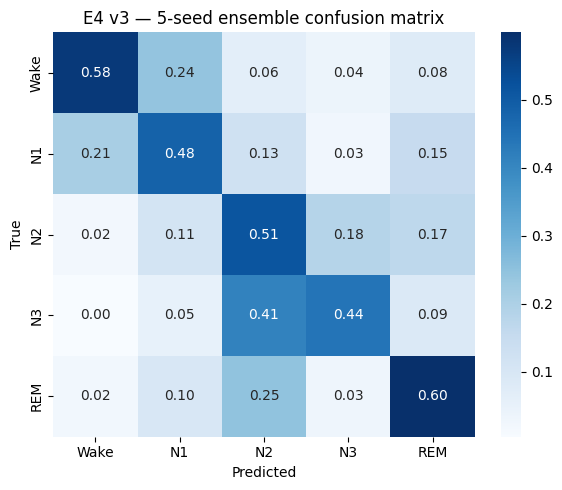

In [1]:
# ============================================================
# E4 v3 (Triple-CNN + BiMamba + SupCon) — 5-SEED ENSEMBLE EVAL
# Loads all 5 best_seed{seed}.pt checkpoints from the v3 training
# script, does soft-voting (averaged softmax probabilities) on
# the test set.
# Run this AFTER the v3 training script has produced
# best_seed42.pt ... best_seed999.pt in EVAL_PATH.
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# PATHS & CONFIG — must match your v3 training script exactly
# ============================================================
E4_PATH       = r"D:\22\AA\preprocess\preprocessed_E4_v3_BHT"
ARTIFACT_PATH = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0\derivatives\eegfloss-v1.0"
EVAL_PATH     = r"D:\22\AA\evaluation\e4_BHT_bitMamSleep_supcon"

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CONTEXT     = 7
WINDOW      = 2 * CONTEXT + 1
BATCH_SIZE  = 64
SEEDS       = [42, 123, 256, 789, 999]
IN_CH         = 3
EPOCH_SAMPLES = 1920

D_MODEL   = 128
D_STATE   = 16
DROPOUT   = 0.4   # irrelevant at eval time (model.eval() disables dropout)
PROJ_DIM  = 64

ARTIFACT_WEIGHT_MAP   = {0: 1.0, 1: 0.0, 2: 0.4, 3: 0.2, 4: 0.1}
TARGET_ART_CHANNELS   = ["PSG_F3:A2", "PSG_C3:A2"]
FALLBACK_ART_CHANNELS = ["PSG_F3", "PSG_C3", "Zmax_EEGL", "Zmax_EEGR"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

TEST_SUBS = np.load(os.path.join(E4_PATH, '_test_subs.npy'), allow_pickle=True).tolist()
print(f"Test subjects: {len(TEST_SUBS)}")


# ============================================================
# ARTIFACT WEIGHT LOADER (identical to training script)
# ============================================================
def load_artifact_weights(subject_id, n_epochs):
    tsv_path = os.path.join(ARTIFACT_PATH, subject_id, "eeg", f"{subject_id}_task-sleep_proc-artifacts.tsv")
    if not os.path.exists(tsv_path):
        return np.ones(n_epochs, dtype=np.float32)
    try:
        df = pd.read_csv(tsv_path, sep='\t')
    except Exception:
        return np.ones(n_epochs, dtype=np.float32)

    available = [ch for ch in TARGET_ART_CHANNELS if ch in df.columns]
    if not available:
        available = [ch for ch in FALLBACK_ART_CHANNELS if ch in df.columns]
    if not available:
        return np.ones(n_epochs, dtype=np.float32)

    df['worst_score'] = df[available].max(axis=1).astype(int)
    df['sleep_epoch'] = ((df['offset'] - 1e-6) // 30).astype(int)
    epoch_scores = df.groupby('sleep_epoch')['worst_score'].max()

    weights = np.ones(n_epochs, dtype=np.float32)
    for ep_idx, score in epoch_scores.items():
        idx = int(ep_idx)
        if 0 <= idx < n_epochs:
            weights[idx] = ARTIFACT_WEIGHT_MAP.get(int(score), 1.0)
    return weights


# ============================================================
# DATASET (identical to v3 training script)
# ============================================================
class E4Dataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data  = []
        self.index = []

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                continue
            with np.load(fp) as d:
                e4     = d['e4'].astype(np.float32)
                labels = d['labels'].copy()

            n = len(labels)
            try:
                with np.load(fp) as d:
                    if 'weights' in d:
                        art_w = d['weights'].astype(np.float32)
                    else:
                        art_w = load_artifact_weights(sub, n)
            except Exception:
                art_w = load_artifact_weights(sub, n)

            if len(art_w) >= n:
                art_w = art_w[:n]
            else:
                art_w = np.concatenate([art_w, np.ones(n - len(art_w), dtype=np.float32)])

            sub_idx = len(self.data)
            self.data.append((e4, labels, art_w))
            for i in range(n):
                self.index.append((sub_idx, i, n, float(art_w[i])))

        total = len(self.index)
        print(f"  Samples: {total:,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n, weight = self.index[idx]
        e4, labels, _ = self.data[sub_idx]

        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            ei = max(0, min(n - 1, center_i + offset))
            window_epochs.append(e4[ei])

        x = np.stack(window_epochs, axis=0)
        y = int(labels[center_i])
        return (
            torch.FloatTensor(x),
            torch.tensor(y, dtype=torch.long),
            torch.tensor(weight, dtype=torch.float32),
        )


print("\nBuilding test dataset...")
test_ds = E4Dataset(TEST_SUBS, E4_PATH)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Ready.")


# ============================================================
# MODEL — identical to v3 training script
# ============================================================
class TripleResCNN(nn.Module):
    def __init__(self, in_ch=3, d_model=D_MODEL, dropout=DROPOUT):
        super().__init__()
        mid = d_model // 3

        def branch(kernel):
            return nn.Sequential(
                nn.Conv1d(in_ch, mid, kernel_size=kernel, stride=4, padding=kernel // 2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(4, 4),
                nn.Conv1d(mid, mid, kernel_size=5, padding=2),
                nn.BatchNorm1d(mid), nn.GELU(), nn.MaxPool1d(2, 2),
                nn.Dropout(dropout),
            )

        self.small  = branch(7)
        self.medium = branch(13)
        self.large  = branch(25)

        with torch.no_grad():
            dummy = torch.zeros(1, in_ch, EPOCH_SAMPLES)
            L_s = self.small(dummy).shape[2]
            L_m = self.medium(dummy).shape[2]
            L_l = self.large(dummy).shape[2]

        target_L = min(L_s, L_m, L_l)
        self.pool_s = nn.AdaptiveAvgPool1d(target_L)
        self.pool_m = nn.AdaptiveAvgPool1d(target_L)
        self.pool_l = nn.AdaptiveAvgPool1d(target_L)

        self.proj = nn.Sequential(
            nn.Conv1d(3 * mid, d_model, kernel_size=1),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

    def forward(self, x):
        fs = self.pool_s(self.small(x))
        fm = self.pool_m(self.medium(x))
        fl = self.pool_l(self.large(x))
        return self.proj(torch.cat([fs, fm, fl], dim=1))


class MambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, d_conv=4, expand=2, dropout=DROPOUT):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_inner = d_model * expand

        self.in_proj = nn.Linear(d_model, self.d_inner * 2, bias=False)
        self.conv1d  = nn.Conv1d(self.d_inner, self.d_inner, kernel_size=d_conv,
                                  padding=d_conv - 1, groups=self.d_inner, bias=True)
        self.x_proj  = nn.Linear(self.d_inner, d_state * 2 + 1, bias=False)
        self.dt_proj = nn.Linear(1, self.d_inner, bias=True)

        A = torch.arange(1, d_state + 1, dtype=torch.float32).unsqueeze(0)
        self.A_log = nn.Parameter(torch.log(A.expand(self.d_inner, -1)))
        self.D     = nn.Parameter(torch.ones(self.d_inner))

        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)
        self.dropout  = nn.Dropout(dropout)

    def ssm_scan(self, x, A, B, C, D):
        B_size, L, d = x.shape
        h = torch.zeros(B_size, d, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for i in range(L):
            xi = x[:, i, :]
            h = h * A.unsqueeze(0) + xi.unsqueeze(-1) * B[:, i, :].unsqueeze(1)
            y = (h * C[:, i, :].unsqueeze(1)).sum(-1) + D * xi
            ys.append(y)
        return torch.stack(ys, dim=1)

    def forward(self, x):
        residual = x
        B, L, _ = x.shape
        xz = self.in_proj(x)
        x_, z = xz.chunk(2, dim=-1)
        x_ = F.silu(self.conv1d(x_.transpose(1, 2))[:, :, :L].transpose(1, 2))
        ssm_p = self.x_proj(x_)
        dt_r, Bp, Cp = ssm_p.split([1, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt_r))
        A = -torch.exp(self.A_log)
        A_disc = torch.exp(dt.unsqueeze(-1) * A.unsqueeze(0).unsqueeze(0)).mean(1).mean(0)
        y = self.ssm_scan(x_, A_disc, Bp, Cp, self.D)
        y = self.out_proj(self.dropout(y * F.silu(z)))
        return self.norm(y + residual)


class BiMambaBlock(nn.Module):
    def __init__(self, d_model=D_MODEL, d_state=D_STATE, dropout=DROPOUT):
        super().__init__()
        self.fwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.bwd = MambaBlock(d_model, d_state, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        fwd = self.fwd(x)
        bwd = torch.flip(self.bwd(torch.flip(x, [1])), [1])
        return self.norm(fwd + bwd)


class E4BitMamSleep(nn.Module):
    def __init__(self, in_ch=IN_CH, d_model=D_MODEL, d_state=D_STATE, n_layers=2, dropout=DROPOUT,
                 n_classes=5, context=CONTEXT, proj_dim=PROJ_DIM):
        super().__init__()
        self.context = context
        self.d_model = d_model

        self.triple_cnn    = TripleResCNN(in_ch, d_model, dropout)
        self.intra_bimamba = nn.Sequential(*[BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)])
        self.inter_pos     = nn.Parameter(torch.randn(1, WINDOW, d_model) * 0.01)
        self.inter_bimamba = nn.Sequential(*[BiMambaBlock(d_model, d_state, dropout) for _ in range(n_layers)])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, n_classes),
        )
        self.projector = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model), nn.GELU(),
            nn.Linear(d_model, proj_dim),
        )

    def forward(self, x):
        B, W, C, T = x.shape
        cnn_out = self.triple_cnn(x.view(B * W, C, T)).permute(0, 2, 1)
        intra = self.intra_bimamba(cnn_out).mean(dim=1).view(B, W, self.d_model)
        inter = self.inter_bimamba(intra + self.inter_pos)
        center = inter[:, self.context, :]
        logits = self.classifier(center)
        proj = F.normalize(self.projector(center), dim=1)
        return logits, proj


# ============================================================
# LOAD ALL 5 SEED MODELS, COLLECT SOFTMAX PROBS
# ============================================================
all_probs   = []
labels_ref  = None
weights_ref = None

for seed in SEEDS:
    ckpt_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    if not os.path.exists(ckpt_path):
        print(f"  WARNING: {ckpt_path} not found, skipping seed {seed}")
        continue

    model = E4BitMamSleep().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()

    seed_probs, seed_labels, seed_weights = [], [], []
    with torch.no_grad():
        for x, y, w in test_loader:
            logits, _ = model(x.to(device))
            probs = F.softmax(logits, dim=1).cpu().numpy()
            seed_probs.append(probs)
            seed_labels.append(y.numpy())
            seed_weights.append(w.numpy())

    seed_probs   = np.concatenate(seed_probs, axis=0)
    seed_labels  = np.concatenate(seed_labels, axis=0)
    seed_weights = np.concatenate(seed_weights, axis=0)

    if labels_ref is None:
        labels_ref, weights_ref = seed_labels, seed_weights
    else:
        assert np.array_equal(labels_ref, seed_labels), "label order mismatch across seeds!"

    seed_acc = accuracy_score(seed_labels, seed_probs.argmax(1))
    print(f"  Seed {seed}: individual test acc = {seed_acc*100:.2f}%")
    all_probs.append(seed_probs)

print(f"\nLoaded {len(all_probs)}/{len(SEEDS)} seed models for ensembling.")

# ============================================================
# ENSEMBLE — soft voting
# ============================================================
avg_probs = np.mean(np.stack(all_probs, axis=0), axis=0)
ens_preds = avg_probs.argmax(axis=1)

ens_acc   = accuracy_score(labels_ref, ens_preds)
ens_f1    = f1_score(labels_ref, ens_preds, average='macro', zero_division=0)
ens_kappa = cohen_kappa_score(labels_ref, ens_preds)
ens_per   = f1_score(labels_ref, ens_preds, average=None, zero_division=0)

clean_mask = weights_ref == 1.0
noisy_mask = (weights_ref > 0) & (weights_ref < 1.0)
c_acc = accuracy_score(labels_ref[clean_mask], ens_preds[clean_mask]) if clean_mask.sum() > 0 else 0.0
n_acc = accuracy_score(labels_ref[noisy_mask], ens_preds[noisy_mask]) if noisy_mask.sum() > 0 else 0.0

print(f"\n{'='*60}")
print("ENSEMBLE RESULT (5-seed soft voting) — E4 v3 (Triple-CNN+BiMamba+SupCon)")
print(f"{'='*60}")
print(f"Accuracy    : {ens_acc*100:.2f}%")
print(f"Macro F1    : {ens_f1:.4f}")
print(f"Cohen Kappa : {ens_kappa:.4f}")
print(f"Clean Acc   : {c_acc*100:.2f}%")
print(f"Noisy Acc   : {n_acc*100:.2f}%")
print(f"\nPer-class F1:")
for i, name in enumerate(LABEL_NAMES):
    bar = chr(9608) * int(ens_per[i] * 16)
    print(f"  {name:6s}: {ens_per[i]:.4f}  {bar}")

print(f"\n{'='*60}")
print("COMPARISON")
print(f"{'='*60}")
print(f"{'Model':<40} {'Acc%':>7} {'F1':>7} {'N1':>7}")
print("-" * 62)
print(f"{'Zmax EEG (BiT-MamSleep ens., 5-seed)':<40} {'84.01':>7} {'0.8016':>7} {'0.5482':>7}")
print(f"{'E4 v3 (this, 5-seed ensemble)':<40} {ens_acc*100:>7.2f} {ens_f1:>7.4f} {ens_per[1]:>7.4f}")
print(f"{'='*62}")

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(labels_ref, ens_preds, labels=list(range(5)))
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("E4 v3 — 5-seed ensemble confusion matrix")
plt.tight_layout()
cm_path = os.path.join(EVAL_PATH, "ensemble_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
print(f"\nConfusion matrix saved: {cm_path}")

# ============================================================
# SAVE ENSEMBLE PREDICTIONS
# ============================================================
np.savez_compressed(
    os.path.join(EVAL_PATH, "ensemble_predictions.npz"),
    probs=avg_probs, preds=ens_preds, labels=labels_ref, weights=weights_ref,
)
print(f"Ensemble predictions saved: {os.path.join(EVAL_PATH, 'ensemble_predictions.npz')}")

EEG test: ['sub-005', 'sub-007', 'sub-014', 'sub-017', 'sub-019', 'sub-023', 'sub-035', 'sub-036', 'sub-038', 'sub-040', 'sub-045', 'sub-068', 'sub-081', 'sub-087', 'sub-093', 'sub-100', 'sub-104', 'sub-105', 'sub-112', 'sub-121']
E4  test: ['sub-005', 'sub-007', 'sub-014', 'sub-017', 'sub-019', 'sub-023', 'sub-035', 'sub-036', 'sub-038', 'sub-040', 'sub-045', 'sub-068', 'sub-081', 'sub-087', 'sub-093', 'sub-104', 'sub-105', 'sub-112', 'sub-121']
Same? False


In [1]:
import pandas as pd

sub = "sub-001"
base = r"D:\22\thesis 3233\Wearanize+_PlugNPlay_v1.0\Wearanize+_PlugNPlay_v1.0"
tsv_path = f"{base}\\{sub}\\eeg\\{sub}_task-sleep_channels.tsv"

df = pd.read_csv(tsv_path, sep='\t')
print(df[df['name'].str.contains('Emp', case=False, na=False)])

Empty DataFrame
Columns: [name, type, units, sampling_frequency, max_val, min_val, duration, description]
Index: []
